**Mount Drive & Load Data**

In [41]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

FILE_PATH = '/content/drive/MyDrive/assignment_june14_2026/Hotel_bookings_final.csv'

df = pd.read_csv(FILE_PATH)
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(30000, 24)


,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


**Check Nulls & Data Types**

In [42]:
print(df.dtypes)
print(df.isnull().sum())

customer_id             int64
property_id             int64
city                   object
star_rating             int64
booking_date           object
check_in_date          object
check_out_date         object
room_type              object
num_rooms_booked        int64
stay_type              object
booking_channel        object
booking_value         float64
costprice               int64
markup                  int64
selling_price           int64
payment_method         object
refund_status          object
refund_amount         float64
channel_of_booking     object
booking_status         object
travel_date            object
cashback              float64
coupon_redeem         float64
Coupon USed?           object
dtype: object
customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type              

**Convert Dates & Create Features**

In [43]:
date_cols = ['booking_date', 'check_in_date', 'check_out_date', 'travel_date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

df['stay_nights'] = (df['check_out_date'] - df['check_in_date']).dt.days
df['lead_time_days'] = (df['check_in_date'] - df['booking_date']).dt.days
df['profit'] = df['selling_price'] - df['costprice']
df['booking_month'] = df['booking_date'].dt.to_period('M')
df['checkin_month'] = df['check_in_date'].dt.month

df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?,stay_nights,lead_time_days,profit,booking_month,checkin_month
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,Confirmed,2024-03-04,5.374694,0.000000,No,2.0,53.0,5981,2024-04,5.0
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,Confirmed,2024-07-19,7.161033,0.000000,No,7.0,39.0,1896,2024-04,5.0
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,Confirmed,2024-03-22,0.000000,0.000000,No,5.0,60.0,7013,2024-04,5.0
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,Confirmed,2024-11-24,7.932170,24.500442,Yes,6.0,17.0,10524,2024-04,4.0
4,40,5,Seattle,5,2024-04-01,NaT,NaT,Deluxe,1,Leisure,...,Cancelled,2024-03-02,0.000000,0.000000,No,NaN,NaN,3746,2024-04,NaN


**Verify Null Pattern (Cancelled/Failed bookings have no check-in dates)**

In [44]:
print(df.groupby('booking_status')[['check_in_date','check_out_date']].apply(lambda x: x.isnull().sum()))

                check_in_date  check_out_date
booking_status                               
Cancelled                5045            5045
Confirmed                   0               0
Failed                    423             423


**Overall Booking Status Distribution**

booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64
booking_status
Confirmed    72.24
Cancelled    20.23
Failed        7.53
Name: proportion, dtype: float64


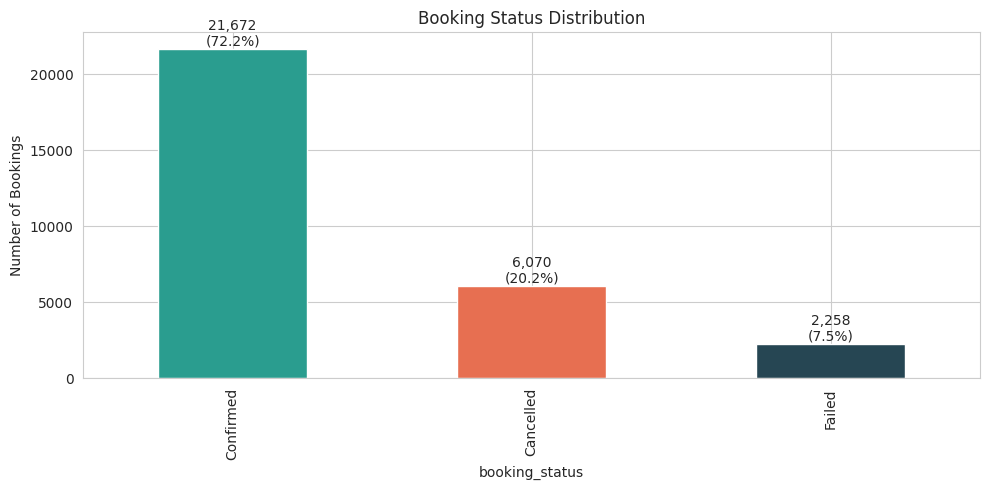

In [45]:
status_counts = df['booking_status'].value_counts()
status_pct = df['booking_status'].value_counts(normalize=True) * 100
print(status_counts)
print(status_pct.round(2))

fig, ax = plt.subplots()
status_counts.plot(kind='bar', ax=ax, color=['#2a9d8f','#e76f51','#264653'])
ax.set_title('Booking Status Distribution')
ax.set_ylabel('Number of Bookings')
for i, v in enumerate(status_counts):
    ax.text(i, v + 200, f'{v:,}\n({status_pct.iloc[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

**Booking Channel Analysis**

In [46]:
channel_summary = df.groupby('booking_channel').agg(
    bookings=('customer_id','count'),
    avg_booking_value=('booking_value','mean'),
    avg_profit=('profit','mean'),
    cancel_rate_pct=('booking_status', lambda x: (x=='Cancelled').mean()*100),
    failed_rate_pct=('booking_status', lambda x: (x=='Failed').mean()*100)
).round(2)
channel_summary

,bookings,avg_booking_value,avg_profit,cancel_rate_pct,failed_rate_pct
booking_channel,,,,,
Mobile App,12009,21351.29,6943.90,21.56,10.90
Travel Agent,2990,24453.97,6931.74,27.93,5.89
Web,15001,28190.84,6985.17,17.64,5.15


Web has the **highest avg value (~28,191)** and **lowest cancellation (17.6%)**; Mobile App has the **highest failure rate (10.9%, ~2x others)**; **Travel Agent** has the **highest cancellation (27.9%).**

**Channel Visualizations**

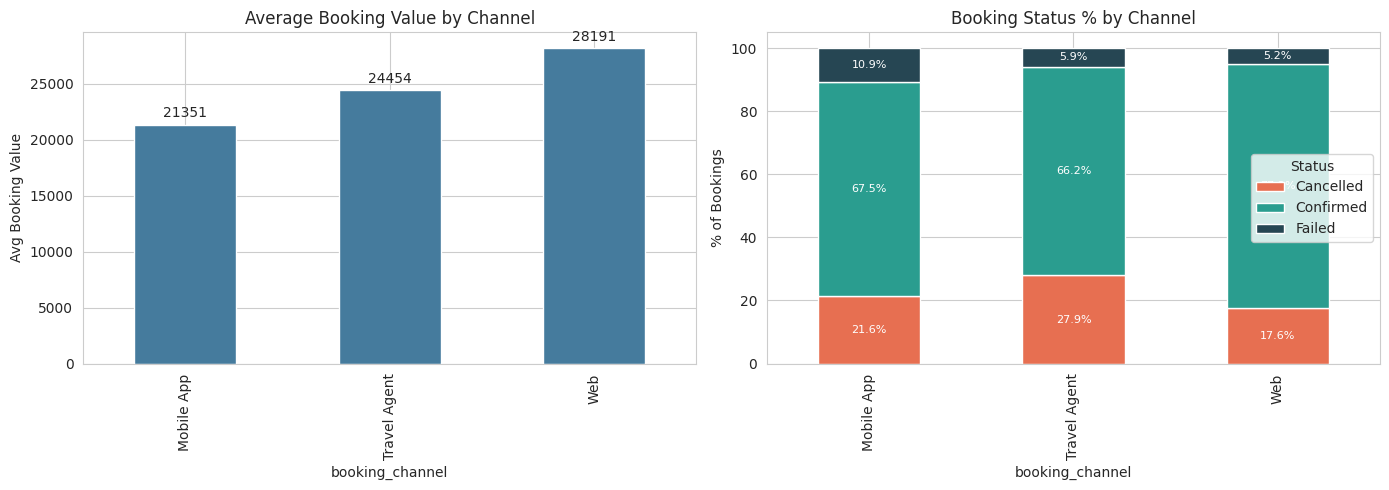

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

bars1 = channel_summary['avg_booking_value'].plot(kind='bar', ax=axes[0], color='#457b9d')
axes[0].set_title('Average Booking Value by Channel')
axes[0].set_ylabel('Avg Booking Value')
axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3)

ct = pd.crosstab(df['booking_channel'], df['booking_status'], normalize='index')*100
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e76f51','#2a9d8f','#264653'])
axes[1].set_title('Booking Status % by Channel')
axes[1].set_ylabel('% of Bookings')
axes[1].legend(title='Status')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=8)
plt.tight_layout()
plt.show()

**Room Type Analysis**

In [48]:
room_summary = df.groupby('room_type').agg(
    bookings=('customer_id','count'),
    avg_booking_value=('booking_value','mean'),
    avg_stay_nights=('stay_nights','mean'),
    cancel_rate_pct=('booking_status', lambda x: (x=='Cancelled').mean()*100)
).round(2)
room_summary

,bookings,avg_booking_value,avg_stay_nights,cancel_rate_pct
room_type,,,,
Deluxe,10478,25004.57,4.03,16.02
Standard,16552,25146.97,4.00,23.30
Suite,2970,24978.21,3.98,17.98


Room type **pricing** is nearly **uniform (~25k)**, but **Standard rooms** cancel far more **(23.3%)** than **Deluxe (16.02%)** or **Suite (17.98%).**

**Room Type Visualizations**

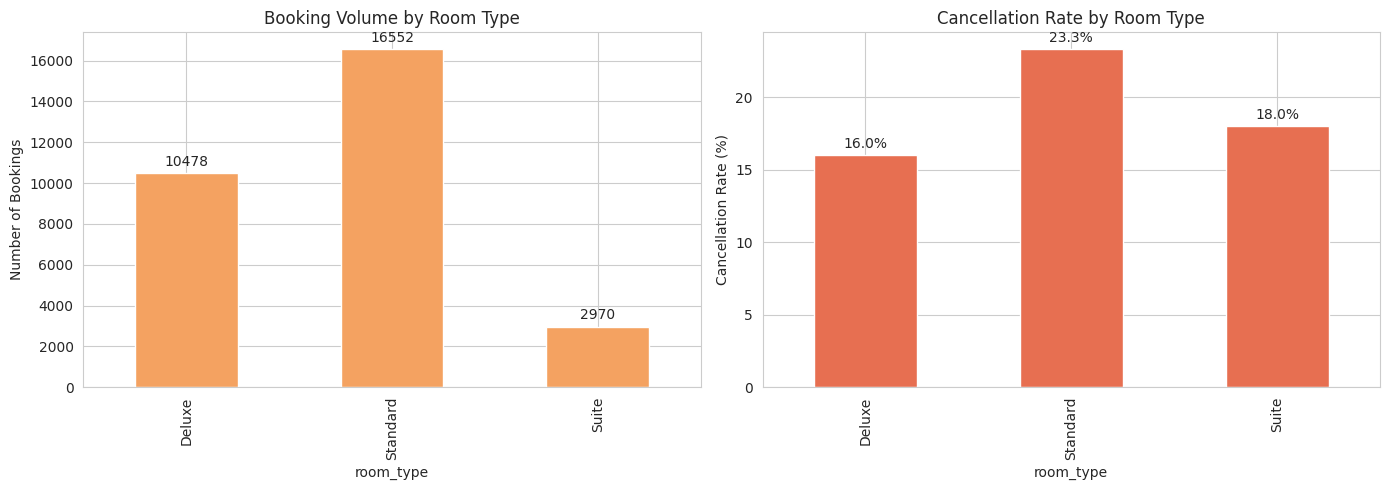

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

room_summary['bookings'].plot(kind='bar', ax=axes[0], color='#f4a261')
axes[0].set_title('Booking Volume by Room Type')
axes[0].set_ylabel('Number of Bookings')
axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3)

room_summary['cancel_rate_pct'].plot(kind='bar', ax=axes[1], color='#e76f51')
axes[1].set_title('Cancellation Rate by Room Type')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

**Star Rating Analysis**

In [50]:
star_summary = df.groupby('star_rating').agg(
    bookings=('customer_id','count'),
    avg_booking_value=('booking_value','mean'),
    cancel_rate_pct=('booking_status', lambda x: (x=='Cancelled').mean()*100),
    failed_rate_pct=('booking_status', lambda x: (x=='Failed').mean()*100)
).round(2)
star_summary

,bookings,avg_booking_value,cancel_rate_pct,failed_rate_pct
star_rating,,,,
2,2995,24855.82,19.77,7.38
3,10460,25209.57,20.20,7.15
4,12034,25010.62,19.99,7.89
5,4511,25116.97,21.26,7.51


Booking value is flat across **star ratings (24,856-25,210)**, but **cancellation rises** slightly **with star rating (19.77% → 21.26%).**

**Star Rating Visualization**

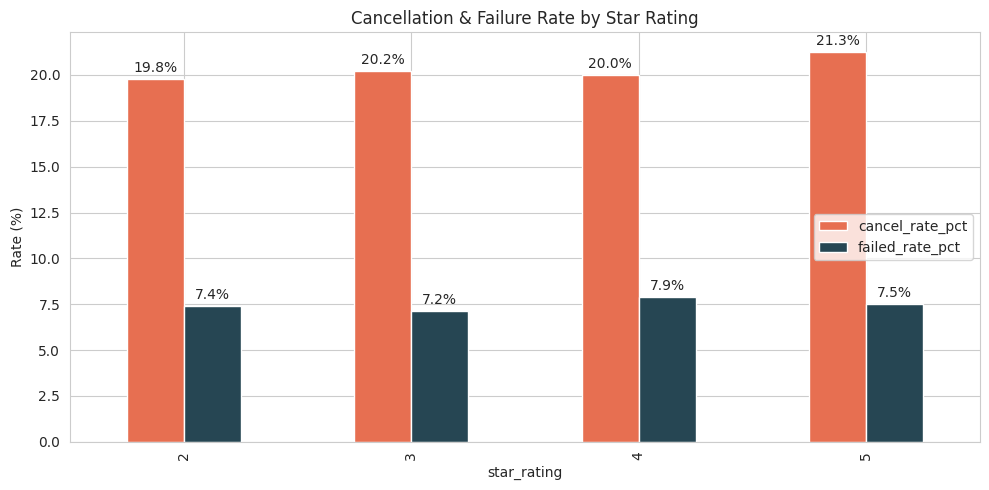

In [51]:
fig, ax = plt.subplots()
star_summary[['cancel_rate_pct','failed_rate_pct']].plot(kind='bar', ax=ax, color=['#e76f51','#264653'])
ax.set_title('Cancellation & Failure Rate by Star Rating')
ax.set_ylabel('Rate (%)')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

**Monthly Trends (Seasonality)**

In [52]:
monthly = df.groupby('booking_month').agg(
    bookings=('customer_id','count'),
    avg_value=('booking_value','mean'),
    cancel_rate_pct=('booking_status', lambda x: (x=='Cancelled').mean()*100)
).round(2)
monthly

,bookings,avg_value,cancel_rate_pct
booking_month,,,
2024-04,2285,22550.85,16.54
2024-05,2360,23197.15,17.29
2024-06,2284,24202.79,17.51
2024-07,2361,25501.59,30.33
2024-08,2360,26064.74,28.77
2024-09,2284,24635.11,17.73
2024-10,2360,24880.62,17.37
2024-11,2285,25753.25,15.93
2024-12,2360,23276.99,25.76


**Seasonality Visualization**

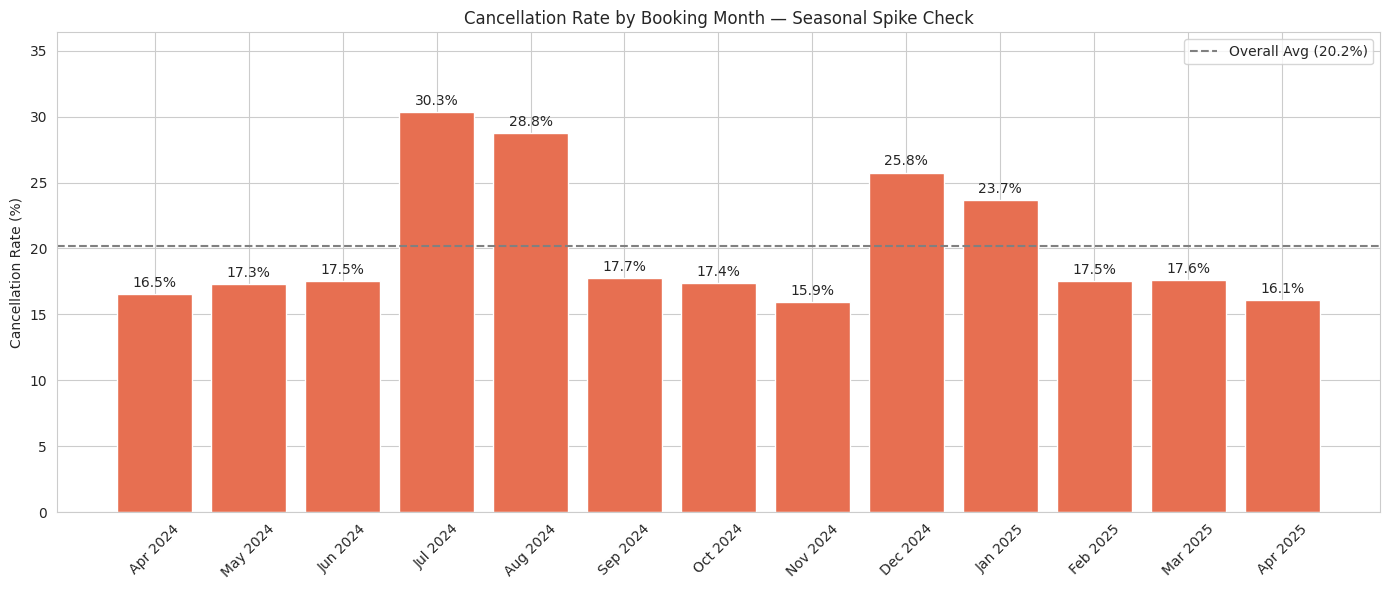

In [53]:
# Dedicated bar chart for seasonal cancellation pattern - clearer than line chart
monthly_display = monthly.copy()
monthly_display.index = monthly_display.index.to_timestamp().strftime('%b %Y')

fig, ax = plt.subplots(figsize=(14,6))
bars = ax.bar(monthly_display.index, monthly_display['cancel_rate_pct'], color='#e76f51')
ax.axhline(monthly_display['cancel_rate_pct'].mean(), color='gray', linestyle='--',
           label=f'Overall Avg ({monthly_display["cancel_rate_pct"].mean():.1f}%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Cancellation Rate by Booking Month — Seasonal Spike Check')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, monthly_display['cancel_rate_pct'].max() * 1.2)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Cancellation** rates spike in **four months — Jul 2024 (30.3%), Aug 2024 (28.8%), Dec 2024 (25.8%), Jan 2025 (23.7%)** — all well above the **~16-18% baseline.** But booking value doesn't move with cancellation in a simple way: **Jul-Aug** have **above-average value (25,500-26,065)** and **high cancellation**;

**Dec-Jan** have **below-average value (23,277-23,424)** AND **high cancellation**; while **Feb-Apr 2025** have the **highest values** in the dataset **(27,300-27,800)** but **normal cancellation (16-17.6%)**.

So booking value alone doesn't predict cancellation — Jul-Aug-Dec-Jan share something else

(likely: **these are the major holiday/travel-planning seasons** — **summer vacations** and **year-end holidays** — where speculative/exploratory bookings are more common regardless of price point), while Feb-Apr's high value comes from stable, non-speculative bookings.

**Refund Behavior for Cancelled Bookings**

In [54]:
cancelled = df[df['booking_status']=='Cancelled']
print(cancelled['refund_status'].value_counts(normalize=True)*100)

refunded = cancelled[cancelled['refund_status']=='Yes']
refund_pct = (refunded['refund_amount'] / refunded['booking_value']) * 100
print('\nRefund amount as % of booking value (cancelled+refunded):')
print(refund_pct.describe())

refund_status
Yes    77.940692
No     22.059308
Name: proportion, dtype: float64

Refund amount as % of booking value (cancelled+refunded):
count    4731.000000
mean        2.422300
std         3.230789
min         0.000000
25%         0.345385
50%         1.585298
75%         3.138076
max        67.573637
dtype: float64


**Cancellation Rate vs Lead Time**

/tmp/ipykernel_3478/3895560278.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_cancel = df_with_lead.groupby('lead_time_bucket')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)


lead_time_bucket
(0, 7]      4.142417
(7, 14]     4.522097
(14, 21]    4.065323
(21, 30]    4.044321
(30, 45]    4.237149
(45, 60]    4.104661
Name: booking_status, dtype: float64


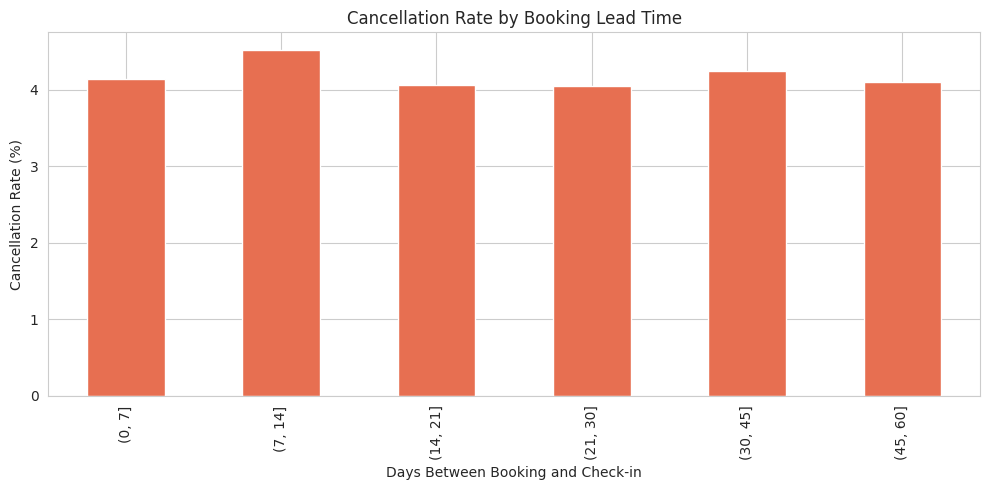

In [60]:
df_with_lead = df.dropna(subset=['lead_time_days']).copy()

bins = [0,7,14,21,30,45,60]
df_with_lead['lead_time_bucket'] = pd.cut(df_with_lead['lead_time_days'], bins=bins)

lead_cancel = df_with_lead.groupby('lead_time_bucket')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)
print(lead_cancel)

fig, ax = plt.subplots()
lead_cancel.plot(kind='bar', ax=ax, color='#e76f51')
ax.set_title('Cancellation Rate by Booking Lead Time')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Days Between Booking and Check-in')
plt.tight_layout()
plt.show()

**Coupon Usage Impact**

In [56]:
coupon_summary = df.groupby('Coupon USed?').agg(
    bookings=('customer_id','count'),
    avg_booking_value=('booking_value','mean'),
    avg_cashback=('cashback','mean'),
    cancel_rate_pct=('booking_status', lambda x: (x=='Cancelled').mean()*100)
).round(2)
coupon_summary

,bookings,avg_booking_value,avg_cashback,cancel_rate_pct
Coupon USed?,,,,
No,23807,25167.90,3.85,20.09
Yes,6193,24744.65,3.74,20.80


**City-Level Analysis**

In [57]:
city_summary = df.groupby('city').agg(
    bookings=('customer_id','count'),
    avg_booking_value=('booking_value','mean'),
    cancel_rate_pct=('booking_status', lambda x: (x=='Cancelled').mean()*100)
).round(2).sort_values('avg_booking_value', ascending=False)
city_summary

,bookings,avg_booking_value,cancel_rate_pct
city,,,
San Francisco,3032,25414.25,19.89
Los Angeles,3040,25365.75,20.92
Boston,2992,25224.13,20.19
Dallas,2935,25221.09,20.00
Chicago,3059,25076.18,20.53
New York,2993,25033.54,20.31
Seattle,2940,25017.52,19.39
Orlando,3015,24900.82,20.50
Miami,2959,24883.60,20.31


**City Visualization**

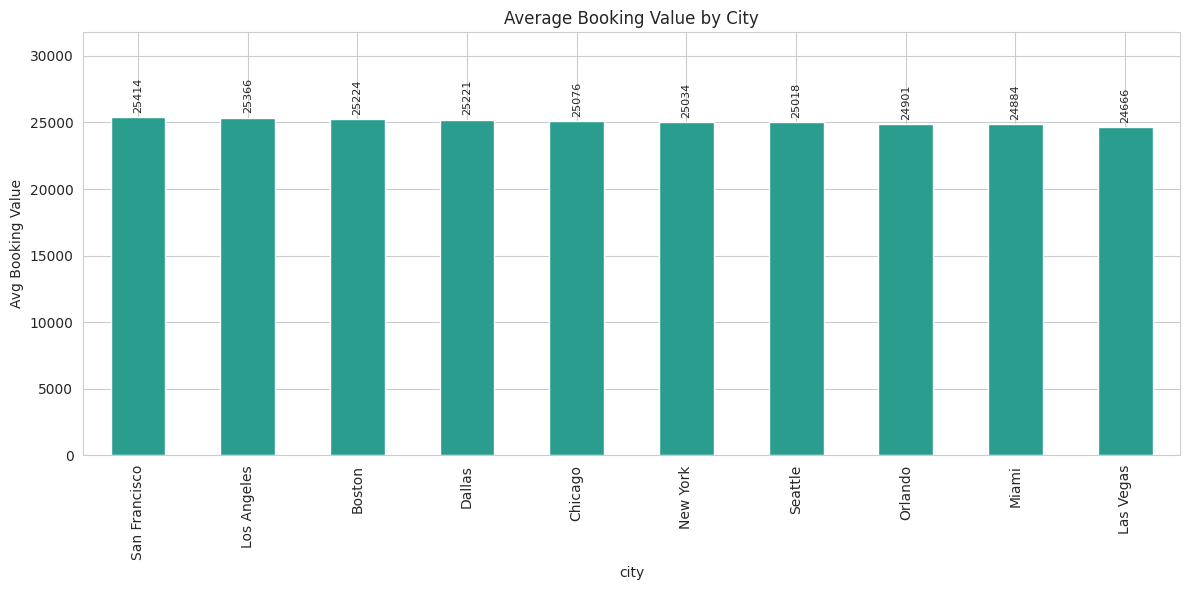

In [58]:
fig, ax = plt.subplots(figsize=(12,6))
city_summary['avg_booking_value'].plot(kind='bar', ax=ax, color='#2a9d8f')
ax.set_title('Average Booking Value by City')
ax.set_ylabel('Avg Booking Value')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, rotation=90, fontsize=8)
ax.set_ylim(0, city_summary['avg_booking_value'].max() * 1.25)
plt.tight_layout()
plt.show()

**Preparing a clean CSV for Looker Studio (Google Data Studio)**

In [61]:
# Export a cleaned/enriched version for Looker Studio
export_df = df.copy()
export_df['booking_month_str'] = export_df['booking_month'].astype(str)
export_df['stay_nights'] = export_df['stay_nights'].fillna(0)
export_df['lead_time_days'] = export_df['lead_time_days'].fillna(-1)

export_df.to_csv('/content/drive/MyDrive/assignment_june14_2026/hotel_bookings_cleaned.csv', index=False)
print("Exported to Drive")

Exported to Drive
